# 07 — SHGAT Graph Visualization

Visualise le graph SHGAT tel qu'il est construit par `db-sync.ts` et `initializer.ts` :
- **Capabilities** (workflow_pattern) = nœuds bleus
- **Tools** (dag_structure→tools_used) = nœuds orange
- **cap→cap** edges (capability_dependency) = arêtes rouges
- **cap→tool** edges (dag_structure) = arêtes grises

Sources DB : PostgreSQL `casys`

In [1]:
import psycopg2
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict

conn = psycopg2.connect(
    host="localhost", port=5432, dbname="casys",
    user="casys", password="Kx9mP2vL7nQ4wRzT"
)
cur = conn.cursor()
print("Connected to casys DB")

Connected to casys DB


In [2]:
# Load capabilities
cur.execute("""
    SELECT pattern_id, 
           COALESCE(dag_structure->>'name', LEFT(pattern_id::text, 8)) as name,
           dag_structure->'tools_used' as tools_used,
           COALESCE(hierarchy_level, 0) as hierarchy_level,
           success_rate
    FROM workflow_pattern
    WHERE code_snippet IS NOT NULL
""")
caps = cur.fetchall()
print(f"Loaded {len(caps)} capabilities")

# Load cap→cap edges
cur.execute("""
    SELECT from_capability_id, to_capability_id, edge_type, edge_source,
           observed_count, confidence_score
    FROM capability_dependency
""")
cap_edges = cur.fetchall()
print(f"Loaded {len(cap_edges)} cap→cap edges")

Loaded 575 capabilities
Loaded 63 cap→cap edges


In [3]:
import json

G = nx.DiGraph()

# Add capability nodes
for cap_id, name, tools_used_raw, hier_level, success_rate in caps:
    cap_node = f"cap:{str(cap_id)[:8]}"
    G.add_node(cap_node, 
               node_type="capability",
               full_id=str(cap_id),
               label=name or str(cap_id)[:8],
               hierarchy_level=hier_level,
               success_rate=float(success_rate or 0))
    
    # Parse tools_used and add cap→tool edges
    tools = []
    if tools_used_raw:
        if isinstance(tools_used_raw, list):
            tools = tools_used_raw
        elif isinstance(tools_used_raw, str):
            try:
                tools = json.loads(tools_used_raw)
            except:
                pass
    
    for tool_id in tools:
        if not tool_id or not isinstance(tool_id, str):
            continue
        # Normalize: remove FQDN prefix if present
        short = tool_id.split('/')[-1] if '/' in tool_id else tool_id
        if not G.has_node(short):
            G.add_node(short, node_type="tool", label=short)
        G.add_edge(cap_node, short, edge_type="contains", edge_source="structural")

# Add cap→cap edges
for from_id, to_id, e_type, e_source, obs_count, conf in cap_edges:
    from_node = f"cap:{str(from_id)[:8]}"
    to_node = f"cap:{str(to_id)[:8]}"
    if G.has_node(from_node) and G.has_node(to_node):
        G.add_edge(from_node, to_node, 
                   edge_type=e_type, edge_source=e_source,
                   observed_count=obs_count, confidence=float(conf or 0))

cap_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'capability']
tool_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'tool']
cap_cap_edges = [(u,v) for u,v,d in G.edges(data=True) if d.get('edge_source') != 'structural']
cap_tool_edges = [(u,v) for u,v,d in G.edges(data=True) if d.get('edge_source') == 'structural']

print(f"Graph: {G.number_of_nodes()} nodes ({len(cap_nodes)} caps, {len(tool_nodes)} tools)")
print(f"Edges: {G.number_of_edges()} total ({len(cap_cap_edges)} cap→cap, {len(cap_tool_edges)} cap→tool)")

Graph: 784 nodes (575 caps, 209 tools)
Edges: 938 total (63 cap→cap, 875 cap→tool)


In [4]:
# Basic stats
tool_degree = Counter()
for tool in tool_nodes:
    tool_degree[tool] = G.in_degree(tool)

cap_out_degree = Counter()
for cap in cap_nodes:
    cap_out_degree[cap] = G.out_degree(cap)

print("=== Top 15 Most-Used Tools (by # capabilities using them) ===")
for tool, count in tool_degree.most_common(15):
    print(f"  {tool:40s} → {count} caps")

print(f"\n=== Tool Degree Distribution ===")
degrees = list(tool_degree.values())
print(f"  Min: {min(degrees)}, Max: {max(degrees)}, Mean: {np.mean(degrees):.1f}, Median: {np.median(degrees):.1f}")
print(f"  Tools used by 1 cap only: {sum(1 for d in degrees if d == 1)} / {len(degrees)}")

print(f"\n=== Cap Out-Degree Distribution (# tools per cap) ===")
out_degrees = list(cap_out_degree.values())
print(f"  Min: {min(out_degrees)}, Max: {max(out_degrees)}, Mean: {np.mean(out_degrees):.1f}, Median: {np.median(out_degrees):.1f}")
print(f"  Caps with 0 tools: {sum(1 for d in out_degrees if d == 0)}")

=== Top 15 Most-Used Tools (by # capabilities using them) ===
  pml.mcp.syson.syson_element_children.6a0c → 39 caps
  pml.mcp.syson.syson_query_aql.6a0c       → 35 caps
  pml.mcp.std.agent_help.db48              → 30 caps
  pml.mcp.syson.syson_element_insert_sysml.6a0c → 28 caps
  pml.mcp.syson.syson_diagram_snapshot.6a0c → 24 caps
  std:data_person                          → 24 caps
  std:data_company                         → 19 caps
  std:crypto_uuid                          → 19 caps
  pml.mcp.plm.plm_bom_generate.5454        → 16 caps
  pml.mcp.plm.plm_bom_flatten.5454         → 16 caps
  pml.mcp.filesystem.read_file.4ff0        → 15 caps
  playwright:browser_wait_for              → 14 caps
  pml.mcp.plm.plm_bom_cost.5454            → 13 caps
  std:crypto_hash                          → 12 caps
  pml.mcp.std.psql_query.db48              → 12 caps

=== Tool Degree Distribution ===
  Min: 1, Max: 39, Mean: 4.2, Median: 2.0
  Tools used by 1 cap only: 88 / 209

=== Cap Out-Degree Dis

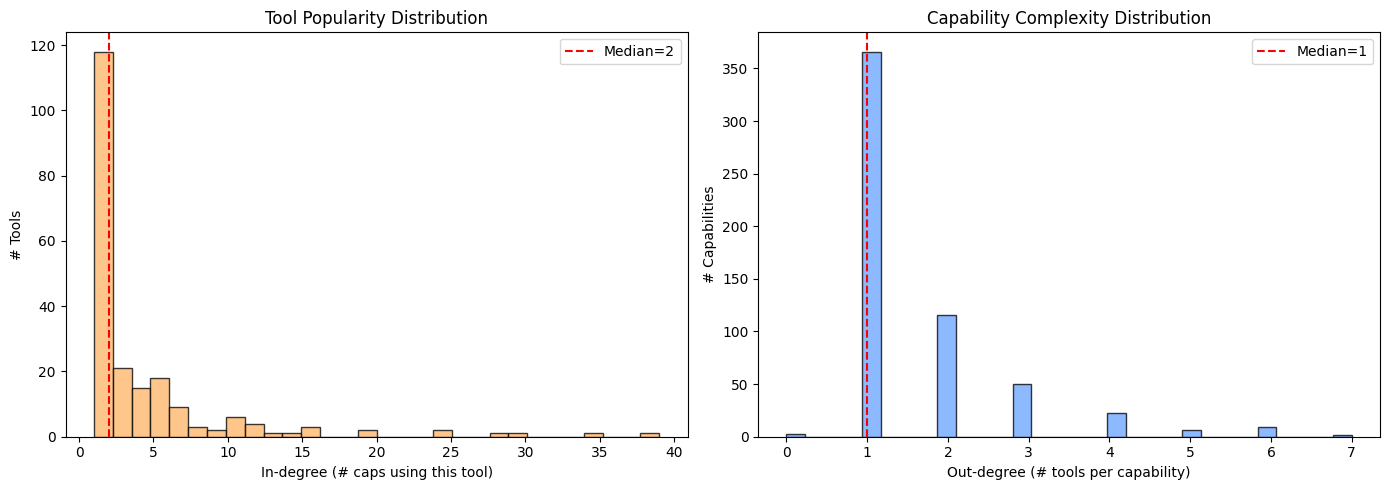

In [5]:
# Tool degree histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degrees, bins=30, color='#FFB86F', edgecolor='#08080a', alpha=0.8)
axes[0].set_xlabel('In-degree (# caps using this tool)')
axes[0].set_ylabel('# Tools')
axes[0].set_title('Tool Popularity Distribution')
axes[0].axvline(np.median(degrees), color='red', linestyle='--', label=f'Median={np.median(degrees):.0f}')
axes[0].legend()

axes[1].hist(out_degrees, bins=30, color='#6FA8FF', edgecolor='#08080a', alpha=0.8)
axes[1].set_xlabel('Out-degree (# tools per capability)')
axes[1].set_ylabel('# Capabilities')
axes[1].set_title('Capability Complexity Distribution')
axes[1].axvline(np.median(out_degrees), color='red', linestyle='--', label=f'Median={np.median(out_degrees):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('07-degree-distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Connected components analysis
G_undirected = G.to_undirected()
components = list(nx.connected_components(G_undirected))
comp_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Connected components: {len(components)}")
print(f"Largest: {comp_sizes[0]} nodes")
if len(comp_sizes) > 1:
    print(f"2nd largest: {comp_sizes[1]} nodes")
print(f"Isolated nodes: {sum(1 for s in comp_sizes if s == 1)}")
print(f"\nComponent size distribution (top 10):")
for i, s in enumerate(comp_sizes[:10]):
    print(f"  Component {i}: {s} nodes")

Connected components: 71
Largest: 259 nodes
2nd largest: 230 nodes
Isolated nodes: 2

Component size distribution (top 10):
  Component 0: 259 nodes
  Component 1: 230 nodes
  Component 2: 31 nodes
  Component 3: 28 nodes
  Component 4: 17 nodes
  Component 5: 9 nodes
  Component 6: 8 nodes
  Component 7: 8 nodes
  Component 8: 7 nodes
  Component 9: 7 nodes


In [7]:
# Tool co-occurrence: which tools appear together most often?
from itertools import combinations

cooccurrence = Counter()
for cap in cap_nodes:
    neighbors = [n for n in G.successors(cap) if G.nodes[n].get('node_type') == 'tool']
    for t1, t2 in combinations(sorted(neighbors), 2):
        cooccurrence[(t1, t2)] += 1

print("=== Top 20 Tool Co-occurrences ===")
for (t1, t2), count in cooccurrence.most_common(20):
    print(f"  {t1:30s} + {t2:30s} → {count} caps")

=== Top 20 Tool Co-occurrences ===
  std:data_company               + std:data_person                → 16 caps
  pml.mcp.plm.plm_bom_cost.5454  + pml.mcp.plm.plm_bom_flatten.5454 → 12 caps
  pml.mcp.syson.syson_element_children.6a0c + pml.mcp.syson.syson_query_aql.6a0c → 10 caps
  pml.mcp.plm.plm_bom_flatten.5454 + pml.mcp.plm.plm_bom_generate.5454 → 9 caps
  std:data_address               + std:data_person                → 9 caps
  code:filter                    + code:map                       → 8 caps
  pml.mcp.plm.plm_bom_cost.5454  + pml.mcp.plm.plm_bom_generate.5454 → 8 caps
  std:crypto_uuid                + std:data_person                → 8 caps
  std:data_address               + std:data_company               → 8 caps
  playwright:browser_snapshot    + playwright:browser_wait_for    → 8 caps
  pml.mcp.syson.syson_diagram_arrange.6a0c + pml.mcp.syson.syson_diagram_drop.6a0c → 7 caps
  pml.mcp.syson.syson_diagram_arrange.6a0c + pml.mcp.syson.syson_diagram_snapshot.6a0c → 7 caps

In [8]:
# Hierarchy level distribution
hier_levels = [G.nodes[n].get('hierarchy_level', 0) for n in cap_nodes]
level_counts = Counter(hier_levels)

print("=== Hierarchy Level Distribution ===")
for level in sorted(level_counts.keys()):
    print(f"  L{level}: {level_counts[level]} capabilities")

# Cap→cap edges analysis  
print(f"\n=== Cap→Cap Edges ({len(cap_cap_edges)} total) ===")
edge_types = Counter()
for u, v, d in G.edges(data=True):
    if d.get('edge_source') != 'structural':
        edge_types[d.get('edge_type', 'unknown')] += 1
for et, cnt in edge_types.most_common():
    print(f"  {et}: {cnt}")

=== Hierarchy Level Distribution ===
  L0: 3 capabilities
  L1: 562 capabilities
  L2: 10 capabilities

=== Cap→Cap Edges (63 total) ===
  contains: 63


In [9]:
# Interactive visualization with pyvis (for the largest component)
from pyvis.network import Network

# Get largest component
largest_comp = max(components, key=len)
subG = G.subgraph(largest_comp).copy()

# If too large, sample: keep top-degree tools + their connected caps
MAX_NODES = 200
if subG.number_of_nodes() > MAX_NODES:
    # Keep top tools by degree + their direct neighbors
    sub_tools = [n for n in subG.nodes() if subG.nodes[n].get('node_type') == 'tool']
    sub_tools_sorted = sorted(sub_tools, key=lambda t: subG.in_degree(t), reverse=True)
    keep_tools = set(sub_tools_sorted[:40])
    keep_nodes = set(keep_tools)
    for tool in keep_tools:
        for pred in subG.predecessors(tool):
            keep_nodes.add(pred)
    # Also keep cap→cap connected caps
    for u, v in cap_cap_edges:
        if u in keep_nodes or v in keep_nodes:
            keep_nodes.add(u)
            keep_nodes.add(v)
    subG = subG.subgraph(keep_nodes).copy()
    print(f"Sampled to {subG.number_of_nodes()} nodes (top-40 tools + neighbors)")

net = Network(height='800px', width='100%', directed=True, 
              bgcolor='#08080a', font_color='white',
              notebook=True, cdn_resources='remote')
net.barnes_hut(gravity=-3000, spring_length=150)

for node, data in subG.nodes(data=True):
    if data.get('node_type') == 'capability':
        label = data.get('label', node)[:20]
        level = data.get('hierarchy_level', 0)
        colors = {0: '#4A90D9', 1: '#6FA8FF', 2: '#A0C4FF'}
        net.add_node(node, label=label, color=colors.get(level, '#A0C4FF'),
                     size=12 + level * 5, title=f"{node}\nL{level}")
    else:
        deg = subG.in_degree(node)
        net.add_node(node, label=node, color='#FFB86F',
                     size=8 + min(deg * 2, 20), 
                     shape='diamond',
                     title=f"{node}\nUsed by {deg} caps")

for u, v, data in subG.edges(data=True):
    if data.get('edge_source') == 'structural':
        net.add_edge(u, v, color='rgba(255,184,111,0.3)', width=1)
    else:
        net.add_edge(u, v, color='#FF6B6B', width=3,
                     title=f"{data.get('edge_type','?')} ({data.get('edge_source','?')})")

net.show('07-shgat-graph.html')
print(f"Saved interactive graph: 07-shgat-graph.html")

Sampled to 214 nodes (top-40 tools + neighbors)
07-shgat-graph.html
Saved interactive graph: 07-shgat-graph.html


In [10]:
# Hub tools analysis: tools that act as "bridges" between many capabilities
# These are the tools that Message Passing will spread signal through
# If MP clusters too much, these hub tools are likely the culprit

print("=== Hub Tools (potential MP clustering culprits) ===")
print("Tools connected to 10+ capabilities — MP spreads through these:\n")

hub_tools = [(t, G.in_degree(t)) for t in tool_nodes if G.in_degree(t) >= 10]
hub_tools.sort(key=lambda x: -x[1])

for tool, deg in hub_tools:
    # What fraction of all caps use this tool?
    pct = 100 * deg / len(cap_nodes)
    print(f"  {tool:40s} {deg:3d} caps ({pct:4.1f}%)")

print(f"\n{len(hub_tools)} hub tools (>= 10 caps)")
print(f"These connect {sum(d for _,d in hub_tools)} cap→tool edges")
print(f"out of {len(cap_tool_edges)} total = {100*sum(d for _,d in hub_tools)/max(len(cap_tool_edges),1):.1f}%")
print("\n→ If MP weight is too high, signal leaks through hub tools")
print("  making all capabilities connected to e.g. 'std:psql_query' look similar.")

=== Hub Tools (potential MP clustering culprits) ===
Tools connected to 10+ capabilities — MP spreads through these:

  pml.mcp.syson.syson_element_children.6a0c  39 caps ( 6.8%)
  pml.mcp.syson.syson_query_aql.6a0c        35 caps ( 6.1%)
  pml.mcp.std.agent_help.db48               30 caps ( 5.2%)
  pml.mcp.syson.syson_element_insert_sysml.6a0c  28 caps ( 4.9%)
  pml.mcp.syson.syson_diagram_snapshot.6a0c  24 caps ( 4.2%)
  std:data_person                           24 caps ( 4.2%)
  std:data_company                          19 caps ( 3.3%)
  std:crypto_uuid                           19 caps ( 3.3%)
  pml.mcp.plm.plm_bom_generate.5454         16 caps ( 2.8%)
  pml.mcp.plm.plm_bom_flatten.5454          16 caps ( 2.8%)
  pml.mcp.filesystem.read_file.4ff0         15 caps ( 2.6%)
  playwright:browser_wait_for               14 caps ( 2.4%)
  pml.mcp.plm.plm_bom_cost.5454             13 caps ( 2.3%)
  std:crypto_hash                           12 caps ( 2.1%)
  pml.mcp.std.psql_query.db48      

In [11]:
# Cleanup
cur.close()
conn.close()
print("Done.")

Done.
